In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [7]:
from google.colab import files

uploaded=files.upload()

Saving fraudTest.csv to fraudTest.csv
Saving fraudTrain.csv to fraudTrain (1).csv


In [8]:
train_df=pd.read_csv("fraudTrain.csv")

test_df=pd.read_csv("fraudTest.csv")

print(train_df.shape)

print(test_df.shape)

(1296675, 23)
(555719, 23)


In [9]:
train_df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [10]:
train_df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [11]:
drop_cols=[

'Unnamed: 0',

'trans_date_trans_time',

'cc_num',

'first',

'last',

'street',

'city',

'state',

'zip',

'dob',

'trans_num'

]

train_df=train_df.drop(columns=drop_cols)

test_df=test_df.drop(columns=drop_cols)

In [12]:
encoder=LabelEncoder()

categorical=train_df.select_dtypes(include='object').columns

for col in categorical:

    train_df[col]=encoder.fit_transform(
        train_df[col].astype(str)
    )

    test_df[col]=encoder.fit_transform(
        test_df[col].astype(str)
    )

In [13]:
train_df["merchant_category"]=(
train_df["category"]*
train_df["merchant"]
)

test_df["merchant_category"]=(
test_df["category"]*
test_df["merchant"]
)

In [14]:
X_train=train_df.drop("is_fraud",axis=1)

y_train=train_df["is_fraud"]

X_test=test_df.drop("is_fraud",axis=1)

y_test=test_df["is_fraud"]

In [15]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

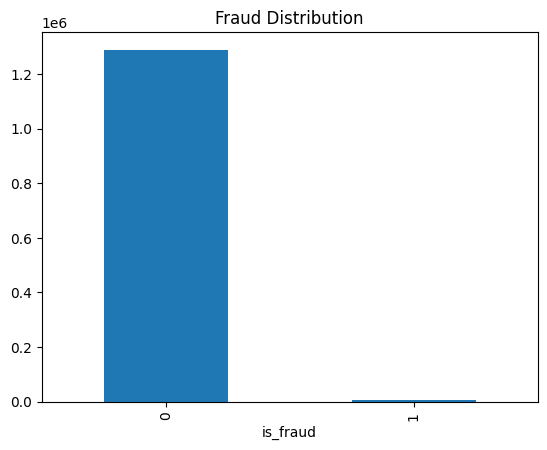

In [16]:
train_df["is_fraud"].value_counts().plot(
kind="bar"
)

plt.title(
"Fraud Distribution"
)

plt.show()

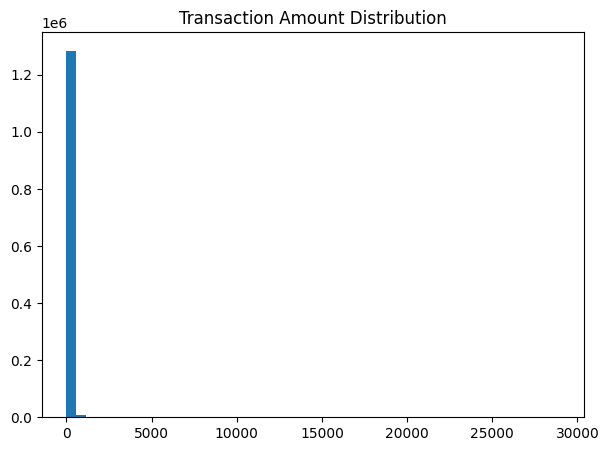

In [17]:
plt.figure(figsize=(7,5))

plt.hist(
train_df["amt"],
bins=50
)

plt.title(
"Transaction Amount Distribution"
)

plt.show()

In [19]:
lr=LogisticRegression()

lr.fit(
X_train,
y_train
)

pred_lr=lr.predict(
X_test
)

In [20]:
print(
"Accuracy:",
accuracy_score(
y_test,
pred_lr
)
)

print(
classification_report(
y_test,
pred_lr
)
)

Accuracy: 0.9955175187459849
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719



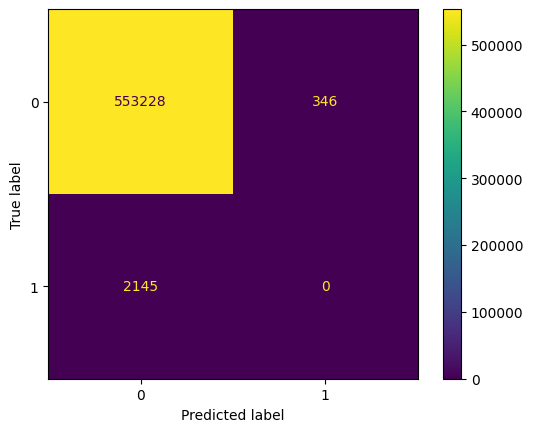

In [21]:
cm=confusion_matrix(
y_test,
pred_lr
)

disp=ConfusionMatrixDisplay(
cm
)

disp.plot()

plt.show()

In [22]:
dt=DecisionTreeClassifier()

dt.fit(
X_train,
y_train
)

pred_dt=dt.predict(
X_test
)

In [23]:
print(
accuracy_score(
y_test,
pred_dt
)
)

print(
classification_report(
y_test,
pred_dt
)
)

0.9928579012054654
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.29      0.58      0.38      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.79      0.69    555719
weighted avg       1.00      0.99      0.99    555719



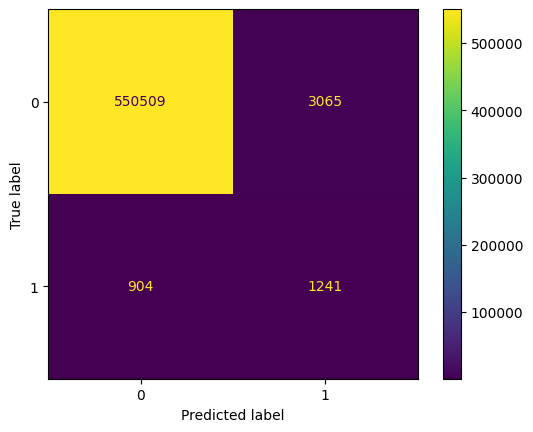

In [24]:
cm=confusion_matrix(
y_test,
pred_dt
)

ConfusionMatrixDisplay(
cm
).plot()

plt.show()

In [25]:
rf=RandomForestClassifier(

n_estimators=100,

random_state=42

)

rf.fit(
X_train,
y_train
)

pred_rf=rf.predict(
X_test
)

In [26]:
print(
accuracy_score(
y_test,
pred_rf
)
)

print(
classification_report(
y_test,
pred_rf
)
)

0.997617500931226
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.76      0.57      0.65      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.78      0.82    555719
weighted avg       1.00      1.00      1.00    555719



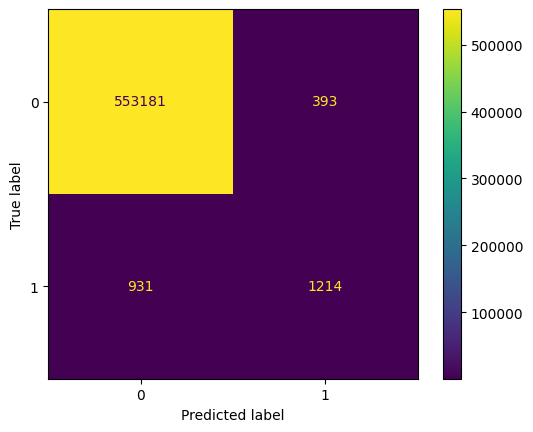

In [27]:
cm=confusion_matrix(
y_test,
pred_rf
)

ConfusionMatrixDisplay(
cm
).plot()

plt.show()

In [28]:
comparison=pd.DataFrame({

"Algorithm":[

"Logistic",

"Decision Tree",

"Random Forest"

],

"Accuracy":[

accuracy_score(
y_test,
pred_lr
),

accuracy_score(
y_test,
pred_dt
),

accuracy_score(
y_test,
pred_rf
)

]

})

comparison.sort_values(
"Accuracy",
ascending=False
)

,Algorithm,Accuracy
2,Random Forest,0.997618
0,Logistic,0.995518
1,Decision Tree,0.992858


In [29]:
best_model=rf

print(
"Selected Model: Random Forest"
)

Selected Model: Random Forest


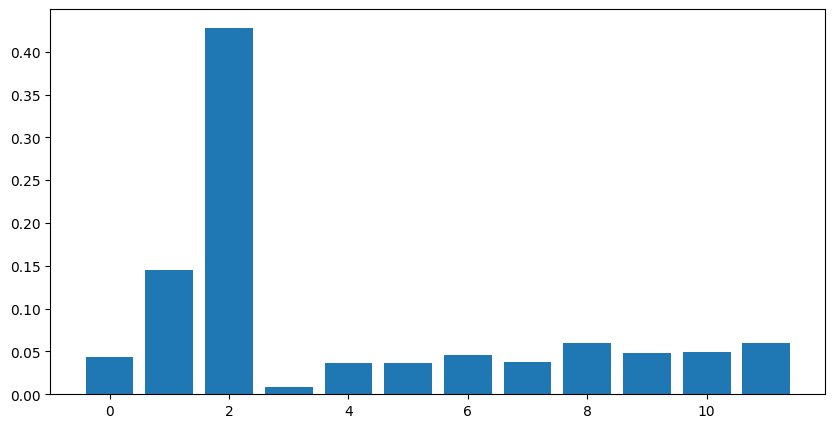

In [30]:
importance=best_model.feature_importances_

plt.figure(
figsize=(10,5)
)

plt.bar(
range(len(importance)),
importance
)

plt.show()

In [31]:
final_pred=best_model.predict(
X_test
)

print(
classification_report(
y_test,
final_pred
)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.76      0.57      0.65      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.78      0.82    555719
weighted avg       1.00      1.00      1.00    555719



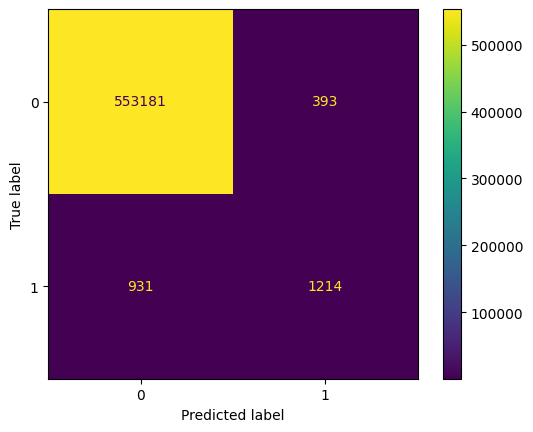

In [32]:
cm=confusion_matrix(
y_test,
final_pred
)

ConfusionMatrixDisplay(
cm
).plot()

plt.show()

In [34]:
def predict_fraud():

    while True:

        print("\nEnter Transaction Details\n")

        amount=float(
            input("Transaction Amount: ")
        )

        category=int(
            input("Encoded Category: ")
        )

        merchant=int(
            input("Encoded Merchant: ")
        )

        city_pop=float(
            input("City Population: ")
        )

        lat=float(
            input("Customer Latitude: ")
        )

        long=float(
            input("Customer Longitude: ")
        )

        merch_lat=float(
            input("Merchant Latitude: ")
        )

        merch_long=float(
            input("Merchant Longitude: ")
        )


        sample=np.zeros(
            X_train.shape[1]
        )


        sample[0]=amount
        sample[1]=category
        sample[2]=merchant
        sample[3]=city_pop
        sample[4]=lat
        sample[5]=long
        sample[6]=merch_lat
        sample[7]=merch_long


        sample=scaler.transform(
            [sample]
        )


        probabilities=best_model.predict_proba(
            sample
        )[0]


        prediction=best_model.predict(
            sample
        )[0]


        fraud_prob=probabilities[1]

        legit_prob=probabilities[0]


        print("\n------ RESULT ------")


        confidence=max(
            probabilities
        )*100


        if confidence<55:

            print(
                "Prediction: Not in our database"
            )

        else:

            if prediction==1:

                print(
                    "Prediction: Fraud Transaction"
                )

            else:

                print(
                    "Prediction: Legitimate Transaction"
                )


        print(
            "Confidence:",
            round(confidence,2),
            "%"
        )


        print(
            "Fraud Probability:",
            round(
                fraud_prob*100,
                2
            ),
            "%"
        )


        print(
            "Legitimate Probability:",
            round(
                legit_prob*100,
                2
            ),
            "%"
        )


        cont=input(
            "\nContinue? (yes/no): "
        ).lower()


        if cont!="yes":

            print(
                "\nPrediction System Closed"
            )

            break


In [ ]:
predict_fraud()


Enter Transaction Details

Transaction Amount: 850
Encoded Category: 3
Encoded Merchant: 12
City Population: 500000
Customer Latitude: 28.61
Customer Longitude: 77.20
Merchant Latitude: 28.60
Merchant Longitude: 77.19

------ RESULT ------
Prediction: Legitimate Transaction
Confidence: 68.0 %
Fraud Probability: 32.0 %
Legitimate Probability: 68.0 %
